In [7]:
import sys
import os

project_root = "D:\\Tesi" 
if project_root not in sys.path:
    sys.path.append(project_root)

import torch
from torch.nn import CrossEntropyLoss
import json
import timm
from NAS.HybridNAS import HybridNAS
from NAS.CompressedViT import CompressedViT
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim import AdamW
from FirstFineTuning.FineTuneUtils import EarlyStopping, train_model, eval_loop, check_top5_accuracy
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
with open("D:\\Tesi\\NAS\\best_architecture.json", "r") as f:
    search_dict = json.load(f)

num_classes = 200
model = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=num_classes)
checkpoint = torch.load("D:\\Tesi\\FirstFineTuning\\best_model.pth")
model.load_state_dict(checkpoint['model_state_dict'])

model = HybridNAS.apply_pruning(search_dict, model)
model = CompressedViT(search_dict, model).to(device)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

new_params = count_params(model)
print(f"Compresso: {new_params / 1e6:.2f}M")

Compresso: 19.45M


In [9]:
data_config = timm.data.resolve_model_data_config(model)
imagenet_mean, imagenet_std = data_config["mean"], data_config["std"]

test_transform = transforms.Compose(
    [transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])

val_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [ ]:
batch_size = 128
N_epochs = 12
lr = 1e-7
weight_decay = 0.0

In [11]:
#creazione dei dataset e dataloader

train_set = ImageFolder("D:\\Tesi\\Sets\\Set1\\train", transform=train_transform)
val_set = ImageFolder("D:\\Tesi\\Sets\\Set1\\val", transform=val_transform)
test_set = ImageFolder("D:\\Tesi\\Places365Simplified\\val", transform=test_transform)

classes = train_set.classes

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

optim = AdamW(model.parameters(), weight_decay=weight_decay)
scheduler = CosineAnnealingLR(optim, T_max=N_epochs, eta_min=1e-7)
loss_fn = CrossEntropyLoss()
early_stopping = EarlyStopping(path="D:\\Tesi\\SecondFineTuning", patience=3 ,min_delta=0.01)

In [12]:
train_loss, val_loss, accuracy = train_model(model, N_epochs, optimizer=optim, device=device,
                                             train_dataloader=train_loader, loss_fn=loss_fn,
                                             early_stopping=early_stopping, val_dataloader=val_loader,
                                             scheduler=scheduler)

Epoch 1: 100%|██████████| 3666/3666 [14:28<00:00,  4.22it/s]


Train_loss: 2.4473
Val loss: 2.0014	Accuracy: 0.4847



Epoch 2:   5%|▍         | 171/3666 [00:50<17:12,  3.39it/s]


KeyboardInterrupt: 

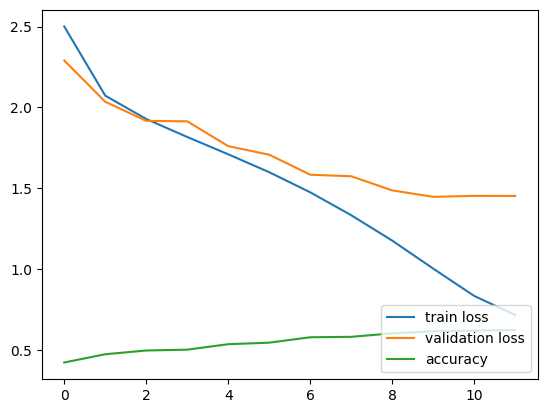

In [ ]:
plt.plot(train_loss, label="train loss")
plt.plot(val_loss, label="validation loss")
plt.plot(accuracy, label='accuracy')
plt.legend(loc='lower right')
plt.show()

In [ ]:
checkpoint = torch.load("D:\\Tesi\\SecondFineTuning\\best_model.pth")
model.load_state_dict(checkpoint['model_state_dict'])
_, _, y_true, y_pred = eval_loop(model, val_loader, loss_fn, device, classes, report=True)
print(f"Top5 accuracy: {check_top5_accuracy(model, val_loader, device):.2f}%")

                            precision    recall  f1-score   support

                  airfield      0.874     0.832     0.852       125
          airport_terminal      0.642     0.560     0.598       125
                     alley      0.615     0.728     0.667       125
              amphitheater      0.724     0.608     0.661       125
          amusement_arcade      0.586     0.792     0.673       125
            amusement_park      0.414     0.328     0.366       125
apartment_building-outdoor      0.592     0.568     0.580       125
                  aquarium      0.623     0.608     0.615       125
                  aqueduct      0.785     0.584     0.670       125
  archaelogical_excavation      0.628     0.568     0.597       125
                   archive      0.547     0.600     0.573       125
         arena-performance      0.611     0.704     0.654       125
               arena-rodeo      0.803     0.816     0.810       125
                 army_base      0.871     0.808